In [1]:
%matplotlib inline

import sys, os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker
from matplotlib import rc, rcParams
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pickle as pkl

# Make use of TeX\ufeff
rc('text',usetex=True)
# Change all fonts to 'Computer Modern'
rc('font',**{'size':14, 'family':'serif','serif':['Times New Roman']})
rc('xtick.major', size=5, pad=7)
rc('xtick', labelsize=15)
rc('ytick.major', size=5, pad=7)
rc('ytick', labelsize=15)

# uses matplotlib-label-lines, see for example https://github.com/cphyc/matplotlib-label-lines
from labellines import labelLine, labelLines

# this needs to point to the folder where darkelf.py is stored
work_dir = os.getcwd()
sys.path.append(work_dir+"/..")
plotdir=work_dir+"/plots/"

from darkelf import darkelf, targets

In [2]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0,exposure=1):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/(R*exposure) # exposure in kg-year (default 1)

# From Example Notebook

In [37]:
targets.list_all()

	 data\Al
	 data\Al2O3
	 data\C
	 data\GaAs
	 data\GaN
	 data\Ge
	 data\Si
	 data\SiC
	 data\SiO2
	 data\Ta
	 data\Xe
	 data\ZnS


In [38]:
targets.files('GaAs')

Available configuration files: 
	 GaAs\GaAs.yaml
 
Available data for epsilon: 
	 GaAs\GaAs_epsphonon_data10K.dat
	 GaAs\GaAs_mermin.dat
 
Available data for phonon (partial) density of states: 
	 GaAs\As_pDoS.dat
	 GaAs\Ga_pDoS.dat
 
Available data for Fn(omega) functions: 
	 GaAs\As_Fn.dat
	 GaAs\Ga_Fn.dat
 
Available data for form factors: 
	 GaAs\As_atomic_Zion.dat
	 GaAs\As_Zion.dat
	 GaAs\Ga_atomic_Zion.dat
	 GaAs\Ga_Zion.dat


In [39]:
mX=1.0e8 # specify the dark matter mass

# create an object for each target material. This reads in precalculated tables for the ELF and interpolates them
# For Si and Ge, we will create a separate darkelf object with the Mermin and GPAW grids, to compare both calculations. 
Si_gpaw = darkelf(target='Si',mX=mX,filename="Si_gpaw_withLFE.dat")
Si = darkelf(target='Si',mX=mX,filename="Si_mermin.dat")

Ge_gpaw = darkelf(target='Ge',mX=mX,filename="Ge_gpaw_withLFE.dat")
Ge = darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat")

GaAs = darkelf(target='GaAs',mX=mX,filename="GaAs_mermin.dat")

GaN = darkelf(target='GaN',mX=mX,filename="GaN_mermin.dat")

Al = darkelf(target='Al',mX=mX,filename="Al_mermin.dat")

SiO2 = darkelf(target='SiO2',mX=mX,filename="SiO2_mermin.dat")

ZnS = darkelf(target='ZnS',mX=mX,filename="ZnS_mermin.dat")

# example on how to load the ELF for the phonon regime
Al2O3 = darkelf(target='Al2O3',mX=mX,filename="Al2O3_mermin.dat",phonon_filename="Al2O3_epsphonon_o.dat") 

target_list=[Al,Al2O3,GaAs,GaN,Ge,Si,SiO2,ZnS]

 .... Loading files for Si
Loaded Si_gpaw_withLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, http

KeyboardInterrupt: 

In [ ]:
Ge_gpaw.e0+Ge_gpaw.E_gap

3.57

In [ ]:
?Si.update_params

Signature:
Si.update_params(
    mX=0,
    delta=0,
    setdelta=False,
    mMed=-1,
    vesckms=0,
    v0kms=0,
    vekms=0,
    mediator='',
    q0=0.0,
    SD_op="A'",
    gp_gn_ratio_val=1,
    set_gp_gn_ratio_val=False,
    gp_gn_ratio='g_n/g_p',
)
Docstring:
Function to update dark matter parameters used in the class.
If the value is set to zero or not set in the arguments, then that means no changes.

Inputs
------
mX: float
    Mass in [eV]
delta: float
    Inelastic splitting in DM states [eV]
    Must set setdelta=True in this case to get delta=0
    Currently just used for DM-electron scattering
mMed: float
    DM-SM mediator mass in eV
    If zero or not set, then default is mMed = 100*mX (massive mediator for NR scattering)
mediator: string
    options: "massless" or "massive"
    setting mMed overrides this option
vesckms: float
    Set vesc in units of km/s
v0kms: float
    Set vesc in units of km/s
vekms: float
    Set vesc in units of km/s
mediator: string 'massive' or

In [ ]:
Si.update_params(mX=1e7, mediator='massless') # set massless mediator limit
Si.DM_params()
print("-------")
Si.update_params(mX=1e6, mMed=10.) # set specific mediator mass. This takes precendent over the "mediator" flag.
Si.DM_params()

mX = 10000000.0 eV
mMed = 0.0 eV
delta = 0.0 eV
-------
mX = 1000000.0 eV
mMed = 10.0 eV
delta = 0.0 eV


In [ ]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/R

# def get_limit(target,mX,vs={"v0kms":220,"vesckms":11},threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
#     target.update_params(mX=mX,mediator=mediator,vesckms=vs["vesckms"],v0kms=vs["v0kms"])
#     R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut)
#     if R==0.0:
#         return 1.0
#     else:
#         return 3.0*1.0e-38/R

In [ ]:
masslist=np.logspace(6,9,50)
kcut=1.2e4 # restrict phase space for massive mediator

# target_list=[Ge,Si,SiO2]
target_list=[Si]

lim_massless=[]
lim_massive=[]
for target in target_list:
    print(target.target)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    
lim_massless=np.array(lim_massless) 
lim_massive=np.array(lim_massive)

Si


In [ ]:
lim_massless

array([[1.00000000e+00, 1.00000000e+00, 1.00000000e+00, 1.00000000e+00,
        4.64581226e-38, 3.64381750e-39, 9.02070351e-40, 3.62068604e-40,
        1.91457781e-40, 1.20846578e-40, 8.66197674e-41, 6.81633835e-41,
        5.74421989e-41, 5.13592484e-41, 4.79929398e-41, 4.63898068e-41,
        4.61487261e-41, 4.69828328e-41, 4.87611719e-41, 5.13857759e-41,
        5.48889291e-41, 5.92602572e-41, 6.45634406e-41, 7.08735147e-41,
        7.83969122e-41, 8.71393405e-41, 9.73896364e-41, 1.09290256e-40,
        1.23081752e-40, 1.38979439e-40, 1.57395130e-40, 1.78653815e-40,
        2.03175937e-40, 2.31448148e-40, 2.64034563e-40, 3.01580033e-40,
        3.44834098e-40, 3.94654904e-40, 4.52038322e-40, 5.18124035e-40,
        5.94228522e-40, 6.81866458e-40, 7.82782339e-40, 8.98984921e-40,
        1.03278796e-39, 1.18685478e-39, 1.36499245e-39, 1.56936578e-39,
        1.80468359e-39, 2.07563265e-39]])

[Text(4.0, 1.8110507445682197e-41, 'Ge')]

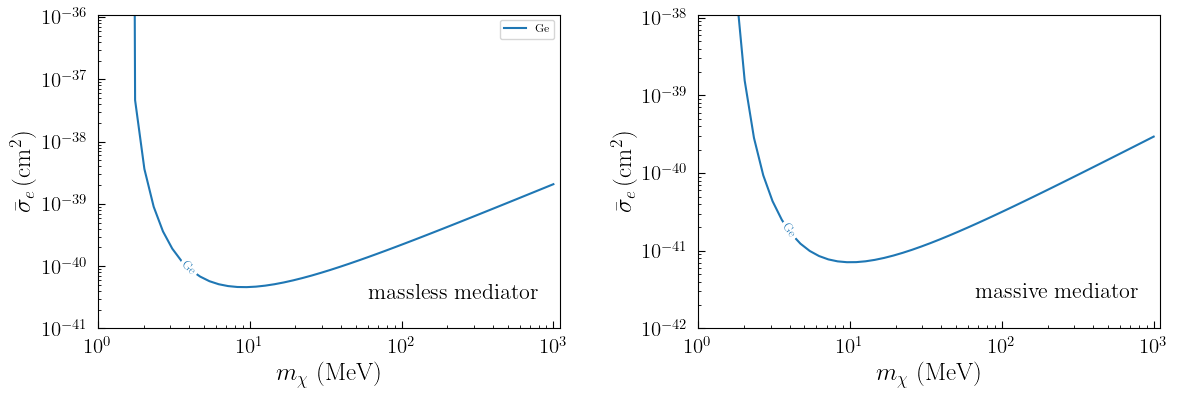

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(12,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
targetlabels=["Ge"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(target_list)):
    axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
    axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs[0].set_xscale("log")   
axs[0].set_yscale("log")
axs[0].set_xlim([1e0,1.1e3])
axs[0].set_ylim([1e-41,1.1e-36])
axs[0].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
axs[0].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs[0].tick_params(direction="in",which="both")
axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs[1].set_xscale("log")   
axs[1].set_yscale("log")  
axs[1].set_xlim([1e0,1.1e3])
axs[1].set_ylim([1e-42,1.1e-38])
axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs[1].tick_params(direction="in",which="both")
axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs[0].legend(ncol=2,fontsize=8)

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs[0].get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs[1].get_lines()
labelLines(lines,fontsize=9,xvals=[4,60,20,8,20,5,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# fig.savefig(plotdir+"darkelf_electron_6.pdf",bbox_inches='tight')

# V scan

In [ ]:
mX=1.0e8 # specify the dark matter mass

# create an object for each target material. This reads in precalculated tables for the ELF and interpolates them
# For Si and Ge, we will create a separate darkelf object with the Mermin and GPAW grids, to compare both calculations. 
Si_gpaw = darkelf(target='Si',mX=mX,filename="Si_gpaw_withLFE.dat")
Si = darkelf(target='Si',mX=mX,filename="Si_mermin.dat")

Ge_gpaw = darkelf(target='Ge',mX=mX,filename="Ge_gpaw_withLFE.dat")
Ge = darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat")

GaAs = darkelf(target='GaAs',mX=mX,filename="GaAs_mermin.dat")

GaN = darkelf(target='GaN',mX=mX,filename="GaN_mermin.dat")

Al = darkelf(target='Al',mX=mX,filename="Al_mermin.dat")

SiO2 = darkelf(target='SiO2',mX=mX,filename="SiO2_mermin.dat")

ZnS = darkelf(target='ZnS',mX=mX,filename="ZnS_mermin.dat")

# example on how to load the ELF for the phonon regime
Al2O3 = darkelf(target='Al2O3',mX=mX,filename="Al2O3_mermin.dat",phonon_filename="Al2O3_epsphonon_o.dat") 

target_list=[Al,Al2O3,GaAs,GaN,Ge,Si,SiO2,ZnS]

 .... Loading files for Si
Loaded Si_gpaw_withLFE.dat for epsilon in electron regime
electronic ELF taken or calculated from J. Enkovaara et al.,Electronic structure calculations with GPAW: a real-space implementation of the projector augmented-wave method,Journal of Physics:Condensed Matter22(2010) 253202.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, http

KeyboardInterrupt: 

In [ ]:
# def get_limit_w_vs(target,mX,vs={"v0kms":220,"vesckms":11},threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
#     target.update_params(mX=mX,mediator=mediator,vesckms=vs["vesckms"],v0kms=vs["v0kms"])
#     R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut)
#     if R==0.0:
#         return 1.0
#     else:
#         return 3.0*1.0e-38/R

def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/R

In [ ]:
print(np.sqrt(43**2 + 11**2))
print(sqrtmrat * 220)
sqrtmrat * np.sqrt(43**2 + 11**2)

44.384682042344295
22000.0


np.float64(4438.468204234429)

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 220,"vesckms":500,"vekms":240,"vdist":"halo","fD":0.01},\
        #    {"v0kms":sqrtmrat * 20,"vesckms":11,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
             {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01}] # all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

Ge
Ge
Ge


NameError: name 'Si' is not defined

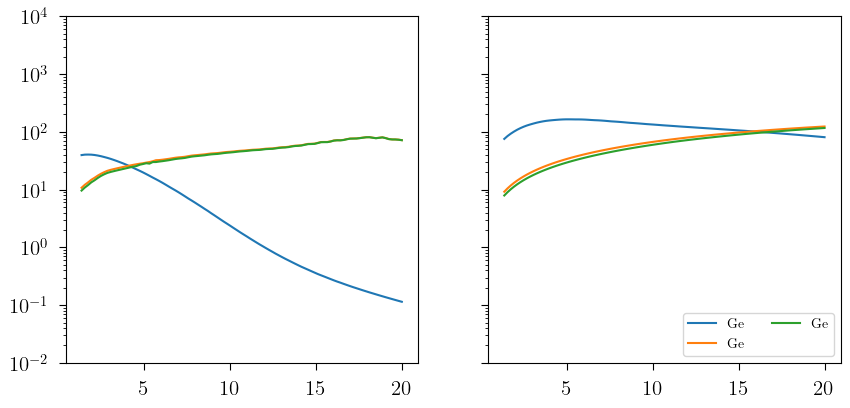

In [ ]:
fig, axs = plt.subplots(1,2,figsize=(10, 4.5),sharey=True)

cmap = plt.get_cmap('Spectral')
colors = cmap(np.linspace(0.0,1.0,8))

for target in target_list:
    print(target.target)
    olist=np.linspace(2.0*target.E_gap,20.0,100)
    
    # massless mediator
    target.update_params(mX=1e8, mediator='massless')
    Rlist=target.dRdomega_electron(olist,method="grid",sigmae=1e-38, kcut=0, withscreening=True,vdist=target.vdist)
    axs[0].plot(olist,Rlist,label=target.target)
    
    # massive mediator
    target.update_params(mX=1e8, mediator='massive')
    Rlist=target.dRdomega_electron(olist,method="grid",sigmae=1e-38, kcut=0, withscreening=True,vdist=target.vdist)
    axs[1].plot(olist,Rlist,label=target.target)
    
    
axs[0].set_yscale("log")
axs[1].legend(ncol=2,fontsize=10,loc="lower right")
axs[0].set_ylim([1e-2,1e4])

axs[0].text(0,4e3,"$m_X=$"+str(int(Si.mX*1e-6))+" MeV",fontsize=14,backgroundcolor="white")
axs[0].text(0,1.5e3,r"$\bar \sigma_e=10^{-38}\,\mathrm{cm}^{2}$",fontsize=14,backgroundcolor="white")
axs[0].text(19.5,4e3,r"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs[1].text(0,4e3,"$m_X=$"+str(int(Si.mX*1e-6))+" MeV",fontsize=14,backgroundcolor="white")
axs[1].text(0,1.5e3,r"$\bar \sigma_e=10^{-38}\,\mathrm{cm}^{2}$",fontsize=14,backgroundcolor="white")
axs[1].text(19.5,4e3,r"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs[0].set_xlabel("$\omega$ [eV]")
axs[1].set_xlabel("$\omega$ [eV]")
axs[0].set_ylabel("$dR/d\omega\, [1/kg/yr/eV]$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.2)


[Text(4.0, 1.0000000000000164, 'Ge - halo, non-aDM'),
 Text(100.0, 2.1911005202919533e-40, 'Ge - halo, aDM'),
 Text(20.0, 8.513601732501325e-42, 'Ge - halo, max charged'),
 Text(8.0, 9.478947848117224e-43, 'Ge - disk, sun lots'),
 Text(1.5, 1.2121586234277977e-43, 'Ge - disk, sun little'),
 Text(10.0, 1.209209185515157e-42, 'Ge - disk, little both')]

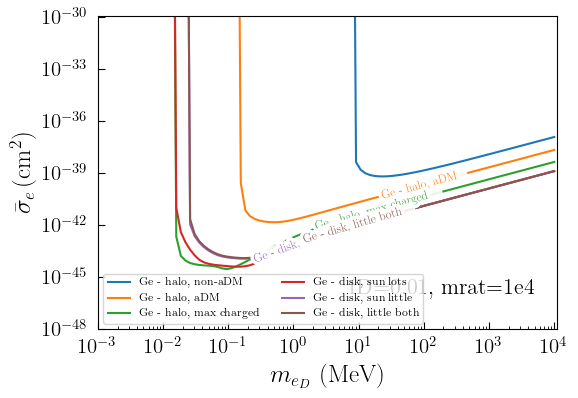

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist * 1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e-3,1.1e4])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (MeV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e3,1e-46,"fD=0.01, mrat=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8)
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
# lines = axs[1].get_lines()
# labelLines(lines,fontsize=9,xvals=[4,60,20,8,20,5,100,10],zorder=2.5,
#            ha='center',va='center',align=True,bbox=props)

# fig.savefig(plotdir+"darkelf_electron_6.pdf",bbox_inches='tight')

[Text(9000000100.0, 3.0231218833571885e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 1.978898117778106e-38, 'Ge - halo, aDM'),
 Text(9000000100.0, 4.0253756692391014e-39, 'Ge - halo, max charged'),
 Text(9000000100.0, 1.2014916460415585e-39, 'Ge - disk, sun lots'),
 Text(9000000100.0, 1.1780465275495896e-39, 'Ge - disk, sun little'),
 Text(9000000100.0, 1.1862684906815596e-39, 'Ge - disk, little both')]

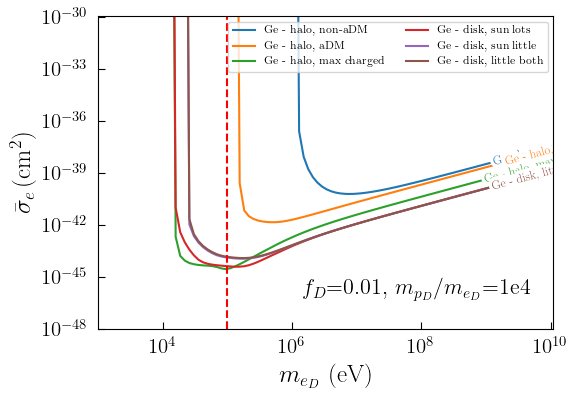

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# V scan with corrected ve

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 220,"vesckms":500,"vekms":240,"vdist":"halo","fD":0.01},\
        #    {"v0kms":sqrtmrat * 20,"vesckms":11,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 220,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 220,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
             {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01}] # all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child7), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 3.0231218833571885e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 9.124290737612587e-32, 'Ge - halo, aDM'),
 Text(9000000100.0, 5.315111757656385e-39, 'Ge - halo, max charged'),
 Text(9000000100.0, 1.2779058666495736e-39, 'Ge - disk, sun lots'),
 Text(9000000100.0, 1.4263038576053844e-39, 'Ge - disk, sun little'),
 Text(9000000100.0, 1.4676646158680774e-39, 'Ge - disk, little both')]

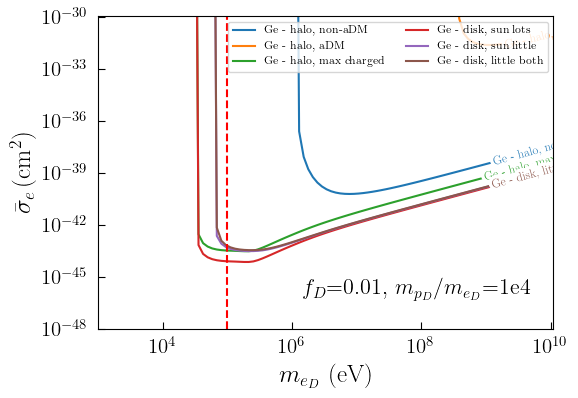

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Monotonicity Sanity Check - halo

In [ ]:
["{}".format(str(x)) for x in (1,2,3)]

['1', '2', '3']

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(n)) for n in np.linspace(1,4,8)]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 2 * 10**n,"vesckms":5 * 10**5,"vekms":240,"vdist":"halo","fD":0.01} for n in np.linspace(1,4,8)]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: overflow encountered in exp
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: invalid value encountered in scalar multiply
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)


Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: overflow encountered in exp
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: invalid value encountered in scalar multiply
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)


Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

...

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: overflow encountered in exp
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: invalid value encountered in scalar multiply
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)


Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: overflow encountered in exp
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: invalid value encountered in scalar multiply
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)


Ge
Ge
Ge
Ge
Ge
Ge
Ge


c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child9), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 9.45027369398465e-38, 'v0 = 1.0'),
 Text(9000000100.0, 8.258135189198697e-38, 'v0 = 1.4285714285714286'),
 Text(9000000100.0, 4.6514708844313713e-38, 'v0 = 1.8571428571428572'),
 Text(9000000100.0, 1.4042680161389504e-38, 'v0 = 2.2857142857142856'),
 Text(9000000100.0, 3.9160345957935383e-39, 'v0 = 2.7142857142857144'),
 Text(9000000100.0, 1.4917313534676117e-39, 'v0 = 3.142857142857143'),
 Text(9000000100.0, 1.432945222404888e-39, 'v0 = 3.571428571428571'),
 Text(9000000100.0, 2.2251249901982576e-39, 'v0 = 4.0')]

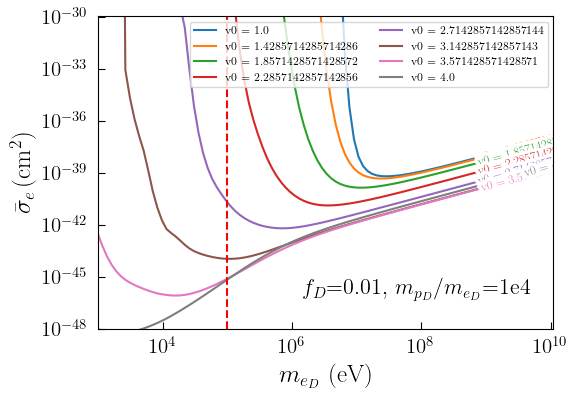

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,np.abs(lim_massless[i]),label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# halo line

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(3))]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 2 * 10**3,"vesckms":10**5,"vekms":240,"vdist":"halo","fD":0.01}]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child2), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(


[Text(9000000100.0, 1.8825481053675286e-39, 'v0 = 3')]

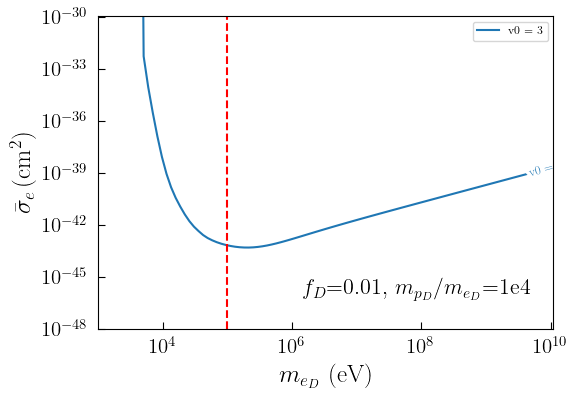

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,np.abs(lim_massless[i]),label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Monotonicity Sanity Check - disk (scrap)

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(n)) for n in np.linspace(1,4,8)]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 2 * 10**n,"vesckms":1.1 * 10**n,"vekms":2 * 10**n,"vdist":"disk","fD":0.01} for n in np.linspace(1,4,8)]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

In [ ]:
lim_massless

array([[1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        1.00000000e+000, 1.00000000e+000, 1.00000000e+000,
        2.25860371e+240, 9.04751550e+200, 1.58315120e+16

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,np.abs(lim_massless[i]),label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
# axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\matplotlib\ticker.py:2468: RuntimeWarning: overflow encountered in power
  ticklocs = b ** decades


OverflowError: cannot convert float infinity to integer

Error in callback <function _draw_all_if_interactive at 0x0000024F78A33F40> (for post_execute), with arguments args (),kwargs {}:


OverflowError: cannot convert float infinity to integer

OverflowError: cannot convert float infinity to integer

<Figure size 600x420 with 1 Axes>

# Monotonicity Sanity Check - disk (fixed vesc)

In [ ]:
print(np.linspace(-0.5,1,8))
{"v0kms": sqrtmrat * 2 * 10**0.5,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2)}

[-0.5        -0.28571429 -0.07142857  0.14285714  0.35714286  0.57142857
  0.78571429  1.        ]


{'v0kms': 632.4555320336759, 'vesckms': np.float64(4438.468204234429)}

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(2 * 10**n)) for n in np.linspace(0.5,2,5)]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": sqrtmrat * 2 * 10**n,"vesckms": sqrtmrat * np.sqrt(43**2 + 11**2) ,"vekms":20,"vdist":"disk","fD":0.01} for n in np.linspace(0.5,2,5)]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child6), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 1.1433490260097885e-39, 'v0 = 6.324555320336759'),
 Text(9000000100.0, 1.15047000700204e-39, 'v0 = 14.997884186649117'),
 Text(9000000100.0, 1.2364346744023237e-39, 'v0 = 35.56558820077846'),
 Text(9000000100.0, 1.5107191800239227e-39, 'v0 = 84.33930068571645'),
 Text(9000000100.0, 2.2361343165953672e-39, 'v0 = 200.0')]

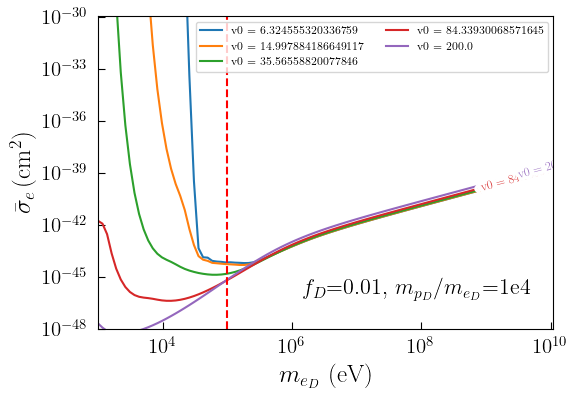

In [ ]:
lim_massless_v0_scan = lim_massless

fig, axs = plt.subplots(figsize=(6,4.2))

# targetlabels=['Al',r'Al$_2$O$_3$',"GaAs","GaN","Ge","Si",r"SiO$_2$","ZnS"]
# targetlabels=["Ge","Si",r"SiO$_2$"]
# targetlabels=["Ge - halo","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(len(target_list)):
#     axs[0].plot(masslist*1e-6,lim_massless[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
for i in range(len(lim_massless)):
    axs.plot(masslist,np.abs(lim_massless[i]),label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_yscale("log")
# axs[0].set_xlim([1e0,1.1e3])
# axs[0].set_ylim([1e-41,1.1e-36])
axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

# axs[1].set_xscale("log")   
# axs[1].set_yscale("log")  
# axs[1].set_xlim([1e0,1.1e3])
# axs[1].set_ylim([1e-42,1.1e-38])
# axs[1].set_xlabel("$m_\chi$ (MeV)",fontsize=18)
# axs[1].set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
# axs[1].tick_params(direction="in",which="both")
# axs[1].text(8e2,2.5e-42,"massive mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# remake vdist plots

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e2

targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



# Plot v dists

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e2

targetlabels=["Ge - halo, non-aDM","Ge - disk, aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

[Text(4.0, 0.33702834656088293, 'Ge - halo, non-aDM'),
 Text(100.0, 0.8453992555056282, 'Ge - disk, aDM'),
 Text(20.0, 0.0, 'Ge - halo, aDM'),
 Text(8.0, 0.0, 'Ge - halo, max charged'),
 Text(1.5, 0.0, 'Ge - disk, sun lots'),
 Text(10.0, 0.0, 'Ge - disk, sun little'),
 Text(100.0, 0.0, 'Ge - disk, little both')]

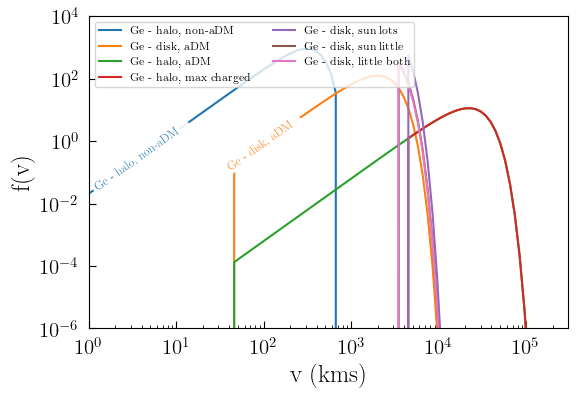

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(flist)):
    axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-6,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel("f(v)",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper left")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 1122.9748745893692, 'Ge - halo, non-aDM'),
 Text(100.0, 168.71793767413524, 'Ge - disk, aDM'),
 Text(20.0, 15.376281330467549, 'Ge - halo, aDM'),
 Text(8.0, 14.852594145241499, 'Ge - halo, max charged'),
 Text(1.5, 61.77544045559996, 'Ge - disk, sun lots'),
 Text(10.0, 79.49277523439821, 'Ge - disk, sun little'),
 Text(100.0, 81.26625771495684, 'Ge - disk, little both')]

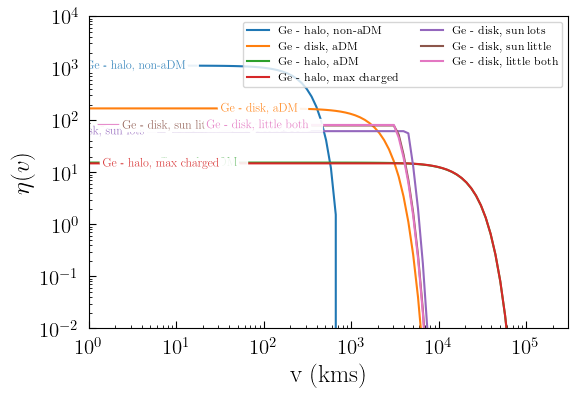

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(etalist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 0.0, 'Ge - halo, non-aDM'),
 Text(100.0, 15.376025537105566, 'Ge - halo, aDM'),
 Text(20.0, 14.852594145241452, 'Ge - halo, max charged')]

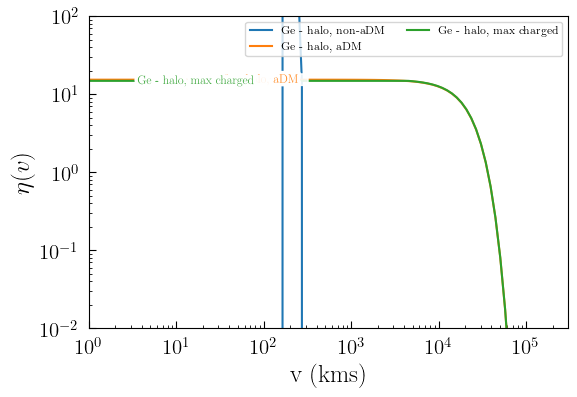

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(3):#len(flist)):
#     axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
for i in range(3):#len(flist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    

axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e2])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

it seems like the distributions for the halo case are not being given the bump that we expect them to be. Maybe its because the bump is proportional to the ratio of vesc / v0, so for the halo case you don't get a large enhancement. If that's true though, then why is there a difference between the maxed charge case and the not max charged case at all? If \eta is the only way the distribution is feeding in they should look identical.

In [ ]:
lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless_DD=np.array(lim_massless) 

Ge
Ge
Ge
Ge
Ge
Ge
Ge


c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child8), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 3.117011057619767e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 1.8903854704144084e-39, 'Ge - disk, aDM'),
 Text(9000000100.0, 2.3497845947358794e-39, 'Ge - halo, aDM'),
 Text(9000000100.0, 2.361537893650103e-39, 'Ge - halo, max charged'),
 Text(9000000100.0, 1.1658731540170846e-39, 'Ge - disk, sun lots'),
 Text(9000000100.0, 1.1830478650144538e-39, 'Ge - disk, sun little'),
 Text(9000000100.0, 1.1877277829036134e-39, 'Ge - disk, little both')]

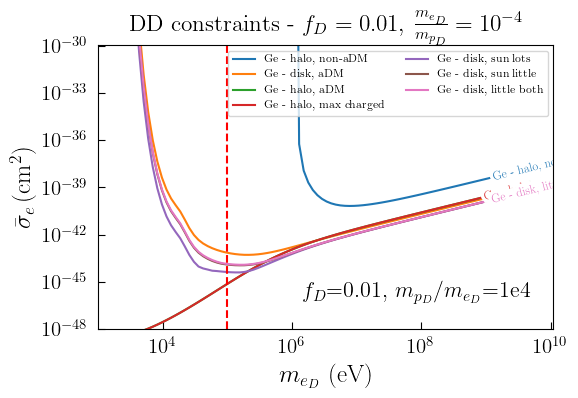

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(9000000100.0, 2.3497845947358794e-39, 'Ge - halo, aDM')]

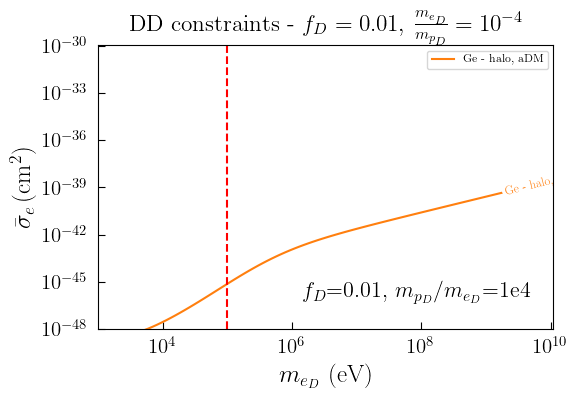

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(2,2):
axs.plot(masslist,lim_massless[1],label=targetlabels[1],color=colors[1])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Plot v dists

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(3))]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 2 * 10**3,"vesckms":10**5,"vekms":240,"vdist":"halo","fD":0.01}]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: overflow encountered in exp
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\mystuff/..\darkelf\__init__.py:352: RuntimeWarning: invalid value encountered in scalar multiply
  self.Nfv_disk = pi**(3/2)*self.v0**3 * exp(zz * zz) * erfc(zz) + pi**(3/2)*self.v0**3 * 2 * zz / pi**(1/2)


Ge


KeyboardInterrupt: 

In [ ]:
testlist = [1,2,3]
testlist.insert(0,4)
testlist

[4, 1, 2, 3]

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e2

targetlabels=["Ge - halo, non-aDM","Ge - disk, aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

[Text(4.0, 0.33702834656088293, 'Ge - halo, non-aDM'),
 Text(100.0, 0.8453992555056282, 'Ge - disk, aDM'),
 Text(20.0, 0.0, 'Ge - halo, aDM'),
 Text(8.0, 0.0, 'Ge - halo, max charged'),
 Text(1.5, 0.0, 'Ge - disk, sun lots'),
 Text(10.0, 0.0, 'Ge - disk, sun little'),
 Text(100.0, 0.0, 'Ge - disk, little both')]

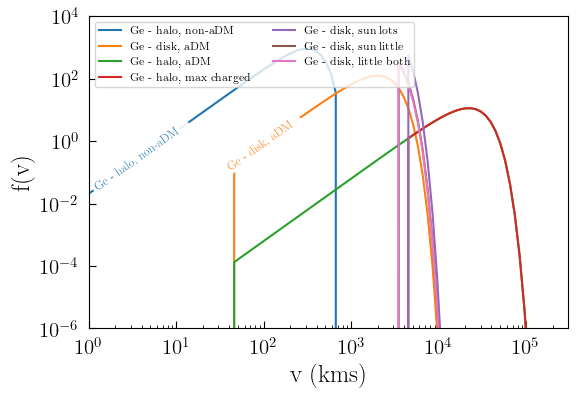

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(flist)):
    axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-6,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel("f(v)",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper left")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 1122.9748745893692, 'Ge - halo, non-aDM'),
 Text(100.0, 168.71793767413524, 'Ge - disk, aDM'),
 Text(20.0, 15.376281330467549, 'Ge - halo, aDM'),
 Text(8.0, 14.852594145241499, 'Ge - halo, max charged'),
 Text(1.5, 61.77544045559996, 'Ge - disk, sun lots'),
 Text(10.0, 79.49277523439821, 'Ge - disk, sun little'),
 Text(100.0, 81.26625771495684, 'Ge - disk, little both')]

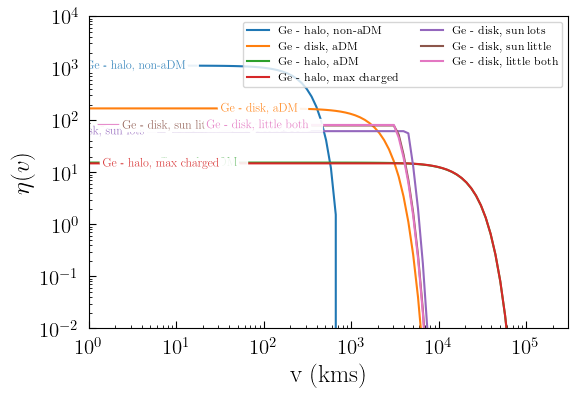

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(etalist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 0.0, 'Ge - halo, non-aDM'),
 Text(100.0, 15.376025537105566, 'Ge - halo, aDM'),
 Text(20.0, 14.852594145241452, 'Ge - halo, max charged')]

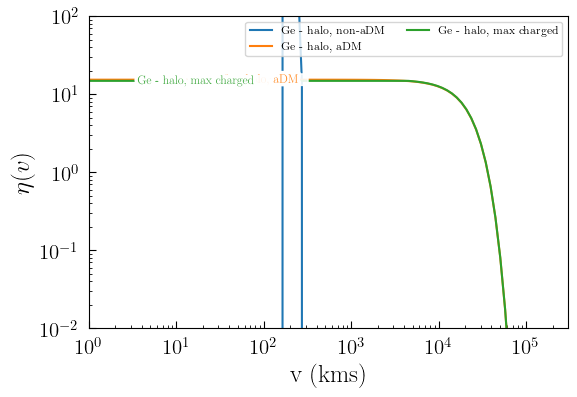

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(3):#len(flist)):
#     axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
for i in range(3):#len(flist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    

axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e2])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

it seems like the distributions for the halo case are not being given the bump that we expect them to be. Maybe its because the bump is proportional to the ratio of vesc / v0, so for the halo case you don't get a large enhancement. If that's true though, then why is there a difference between the maxed charge case and the not max charged case at all? If \eta is the only way the distribution is feeding in they should look identical.

In [ ]:
lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless_DD=np.array(lim_massless) 

Ge
Ge
Ge
Ge
Ge
Ge
Ge


c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child8), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 3.117011057619767e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 1.8903854704144084e-39, 'Ge - disk, aDM'),
 Text(9000000100.0, 2.3497845947358794e-39, 'Ge - halo, aDM'),
 Text(9000000100.0, 2.361537893650103e-39, 'Ge - halo, max charged'),
 Text(9000000100.0, 1.1658731540170846e-39, 'Ge - disk, sun lots'),
 Text(9000000100.0, 1.1830478650144538e-39, 'Ge - disk, sun little'),
 Text(9000000100.0, 1.1877277829036134e-39, 'Ge - disk, little both')]

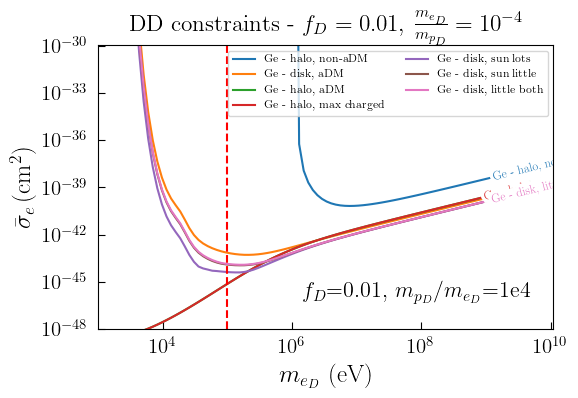

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(9000000100.0, 2.3497845947358794e-39, 'Ge - halo, aDM')]

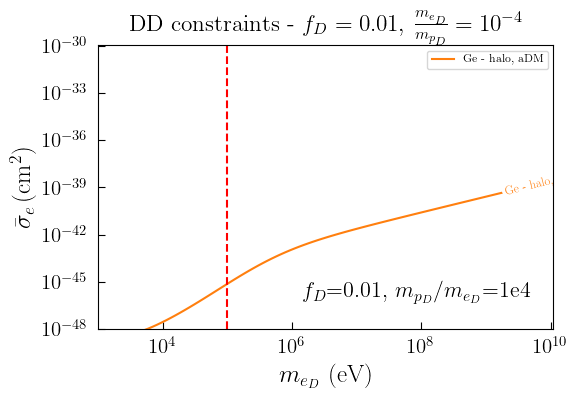

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(2,2):
axs.plot(masslist,lim_massless[1],label=targetlabels[1],color=colors[1])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Plot v dists - dark proton

In [3]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e0

targetlabels=["Ge - halo, non-aDM","Ge - disk, aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":0.1,"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":0.1,"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 ),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti

[Text(4.0, 0.33702834656088304, 'Ge - halo, non-aDM'),
 Text(100.0, 0.0012479148668694162, 'Ge - disk, aDM'),
 Text(20.0, 0.0, 'Ge - halo, aDM'),
 Text(8.0, 4.075752899339417, 'Ge - halo, max charged'),
 Text(1.5, 189.6785763497929, 'Ge - disk, sun lots'),
 Text(10.0, 0.0, 'Ge - disk, sun little'),
 Text(100.0, 0.00013990370230406032, 'Ge - disk, little both')]

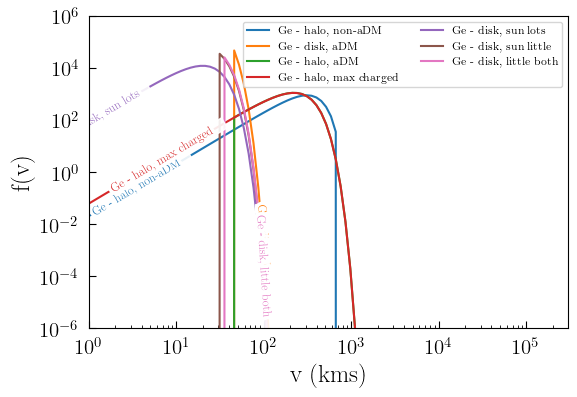

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(flist)):
    axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-6,1e6])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel("f(v)",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 1122.974874589369, 'Ge - halo, non-aDM'),
 Text(100.0, 2.5931916701066638e-05, 'Ge - disk, aDM'),
 Text(20.0, 1485.259414524147, 'Ge - halo, aDM'),
 Text(8.0, 1535.5951324055745, 'Ge - halo, max charged'),
 Text(1.5, 16818.86966772022, 'Ge - disk, sun lots'),
 Text(10.0, 8316.645444406491, 'Ge - disk, sun little'),
 Text(100.0, 2.907226486868478e-06, 'Ge - disk, little both')]

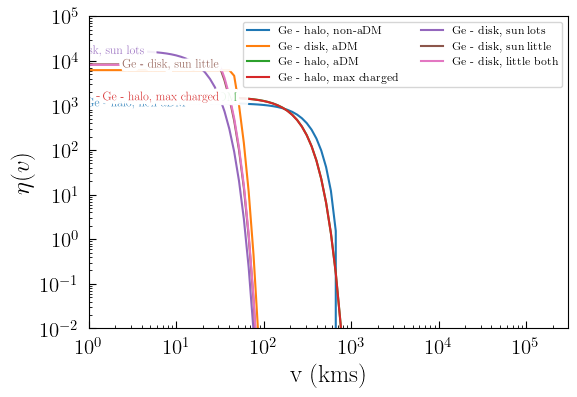

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(etalist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e5])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

it seems like the distributions for the halo case are not being given the bump that we expect them to be. Maybe its because the bump is proportional to the ratio of vesc / v0, so for the halo case you don't get a large enhancement. If that's true though, then why is there a difference between the maxed charge case and the not max charged case at all? If \eta is the only way the distribution is feeding in they should look identical.

In [ ]:
lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless_DD=np.array(lim_massless) 

Ge
Ge
Ge
Ge
Ge
Ge
Ge


c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child7), but could not find a label for it.
  warnings.warn(


[Text(9000000100.0, 3.117011057619767e-38, 'Ge - halo, non-aDM'),
 Text(9000000100.0, 9.933454201228155e-35, 'Ge - disk, aDM'),
 Text(9000000100.0, 5.985877426709293e-38, 'Ge - halo, aDM'),
 Text(9000000100.0, 6.022179837185448e-38, 'Ge - halo, max charged'),
 Text(9000000100.0, 2.6769558428844374e-33, 'Ge - disk, sun lots'),
 Text(9000000100.0, 5.4069139647017345e-34, 'Ge - disk, sun little'),
 Text(9000000100.0, 4.7789331756483235e-34, 'Ge - disk, little both')]

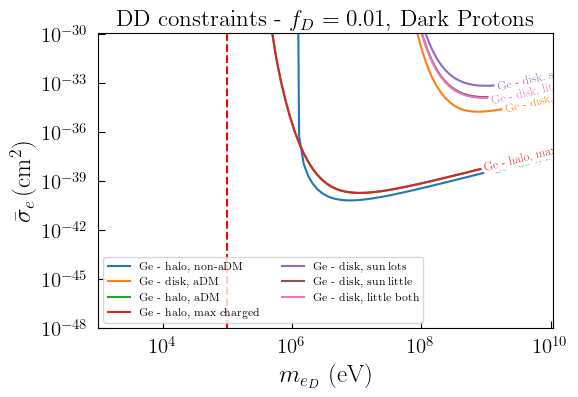

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e4,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="lower left")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"DD constraints - $f_D = 0.01$, Dark Protons")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child2), but could not find a label for it.
  warnings.warn(


[Text(9000000100.0, 9.93345420122795e-35, 'Ge - disk, aDM')]

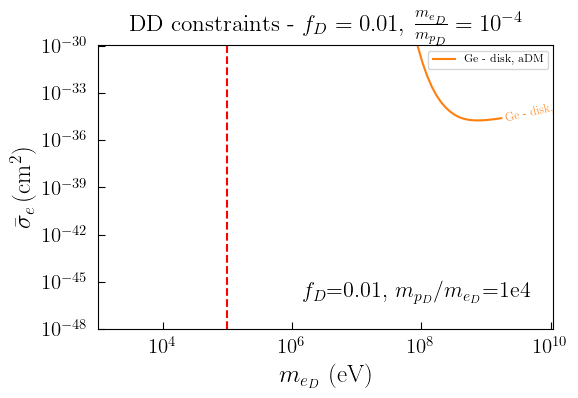

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(2,2):
axs.plot(masslist,lim_massless[1],label=targetlabels[1],color=colors[1])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Plot v dists - Dark Proton - SENSEI and Xenon Limits (28/4/26)

In [3]:
masslist=np.logspace(6,15,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

sqrtmrat = 1e0

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

targetlabels=["Si - halo, non-aDM","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":0.1,"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":0.1,"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 ),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

[Text(4.0, 0.33702834656088293, 'Si - halo, non-aDM'),
 Text(100.0, 0.0012479148668694162, 'Si - disk, aDM'),
 Text(20.0, 0.0, 'Si - halo, aDM'),
 Text(8.0, 4.0757528993394, 'Si - halo, max charged'),
 Text(1.5, 189.67857634979228, 'Si - disk, sun lots'),
 Text(10.0, 0.0, 'Si - disk, sun little'),
 Text(100.0, 0.00013990370230406002, 'Si - disk, little both')]

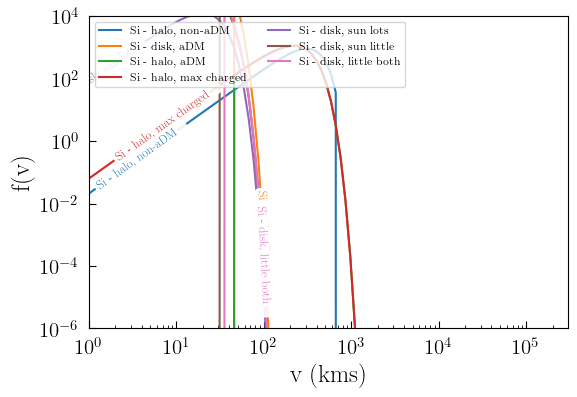

In [4]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(flist)):
    axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-6,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel("f(v)",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper left")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 1122.9748745893692, 'Si - halo, non-aDM'),
 Text(100.0, 2.5931916701066638e-05, 'Si - disk, aDM'),
 Text(20.0, 1485.2594145241499, 'Si - halo, aDM'),
 Text(8.0, 1535.5951324055777, 'Si - halo, max charged'),
 Text(1.5, 16818.86966772024, 'Si - disk, sun lots'),
 Text(10.0, 8316.645444406526, 'Si - disk, sun little'),
 Text(100.0, 2.907226486868478e-06, 'Si - disk, little both')]

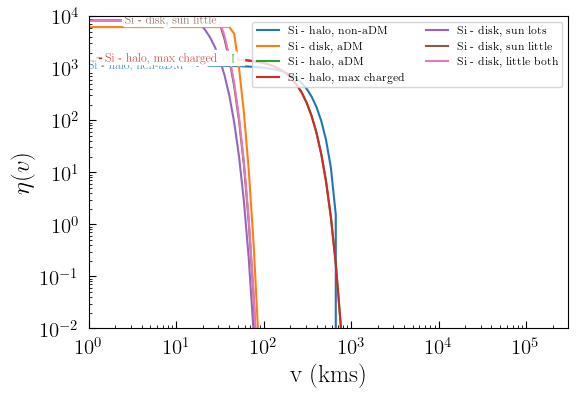

In [5]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(etalist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

it seems like the distributions for the halo case are not being given the bump that we expect them to be. Maybe its because the bump is proportional to the ratio of vesc / v0, so for the halo case you don't get a large enhancement. If that's true though, then why is there a difference between the maxed charge case and the not max charged case at all? If \eta is the only way the distribution is feeding in they should look identical.

In [ ]:
lim_massless=[]

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless_DD=np.array(lim_massless) 

Si


In [ ]:
task = ("write","read")[0]

# test_read = np.array([])

if task == "write":
    with open("lim_massless_SENSEI_exp_pD_28_4_22", "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open("lim_massless_SENSEI_exp_pD_28_4_22", "rb") as f:
        test_read = pkl.load(f)

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child8), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 6.976804069271544e-35, 'Si - halo, non-aDM'),
 Text(9000000100.0, 2.9428028759285916e-36, 'Si - disk, aDM'),
 Text(9000000100.0, 3.9168290132978904e-36, 'Si - halo, aDM'),
 Text(9000000100.0, 3.9382822866563894e-36, 'Si - halo, max charged'),
 Text(9000000100.0, 1.8112817969479025e-36, 'Si - disk, sun lots'),
 Text(9000000100.0, 1.8187637138277805e-36, 'Si - disk, sun little'),
 Text(9000000100.0, 1.8244063282626823e-36, 'Si - disk, little both')]

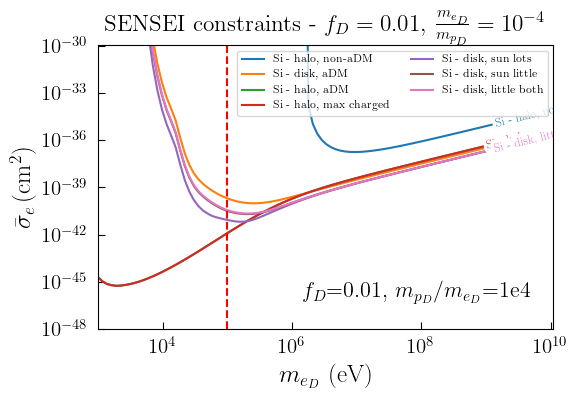

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"SENSEI constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

In [ ]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

lim_kappa = [sigmae_to_kappa_exact(lim_massless[i], masslist) for i in range(len(lim_massless))]

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(9999999999.999918), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(9999999999.999918), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 2 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(9999999999.999918), xval=20)

[Text(9000000099.999926, 2.2247908321296107e-10, 'Si - halo, non-aDM'),
 Text(9000000099.999926, 4.569208105526313e-11, 'Si - disk, aDM'),
 Text(9000000099.999926, 5.271420027160026e-11, 'Si - halo, aDM'),
 Text(9000000099.999926, 5.285836634059556e-11, 'Si - halo, max charged'),
 Text(9000000099.999926, 3.584704234390484e-11, 'Si - disk, sun lots'),
 Text(9000000099.999926, 3.592100363960781e-11, 'Si - disk, sun little'),
 Text(9000000099.999926, 3.5976682034810325e-11, 'Si - disk, little both')]

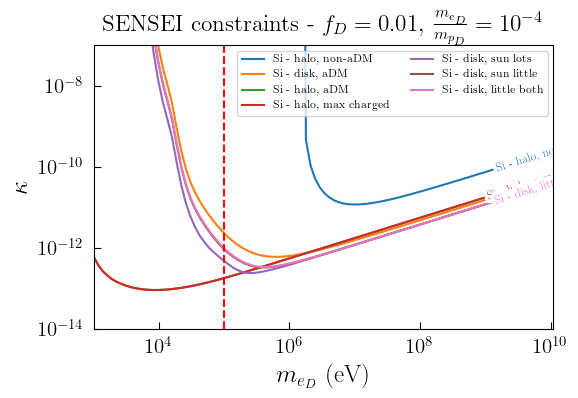

In [ ]:
fig2, axs2 = plt.subplots(figsize=(6,4.2))

for i in range(len(lim_kappa)):
    axs2.plot(masslist, lim_kappa[i], label=targetlabels[i], color=colors[i])

axs2.set_xscale("log")   
axs2.set_yscale("log")

axs2.set_xlim([1e3,1.1e10])

# choose automatic y-limits from the converted curves
# ymin = min(np.nanmin(arr[np.isfinite(arr) & (arr > 0)]) for arr in lim_kappa)
# ymax = max(np.nanmax(arr[np.isfinite(arr)]) for arr in lim_kappa)
axs2.set_ylim([1e-14, 1e-7])

axs2.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs2.set_ylabel(r"$\kappa$",fontsize=18)
axs2.tick_params(direction="in",which="both")

# axs2.text(5e9, 1e-13, "$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",
        #   fontsize=16, backgroundcolor="white", horizontalalignment="right")

axs2.legend(ncol=2,fontsize=8,loc="upper right")
axs2.axvline(x=1e5,color="red",linestyle="dashed")
axs2.set_title(r"SENSEI constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig2.tight_layout()
fig2.subplots_adjust(wspace = 0.3)

props = dict(facecolor='white', alpha=0.9, edgecolor='white', boxstyle="square,pad=0.02")
lines2 = axs2.get_lines()
labelLines(lines2,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

### Now Nuclear

In [ ]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    if R == 0.0:
        return 1.0
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [ ]:
lim_massless=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
        )
        for mX in masslist
    ])

lim_massless_DD = np.array(lim_massless)

Si
Si
Si
Si
Si
Si
Si


In [ ]:
alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    """
    Inverse of sigmae_to_kappa_exact using the same convention:
        kappa = (alpha m_e^2 / (4 sqrt(pi) mu)) * sqrt(sigmae)

    Therefore:
        sigmae = [4 sqrt(pi) mu kappa / (alpha m_e^2)]^2

    Inputs
    ------
    kappa : float or array
        Millicharge / kinetic-mixing parameter in your convention.
    mchi_eV : float or array
        DM mass in eV.

    Returns
    -------
    sigmae_cm2 : float or array
        Reference electron cross section in cm^2
    """
    mu = mu_chie_GeV(mchi_eV)

    pref = (4*np.sqrt(np.pi) * mu * np.asarray(kappa, dtype=float)) / (alpha * m_e_GeV**2)

    sigmae_GeVminus2 = pref**2

    return sigmae_GeVminus2 * cm2_per_GeVminus2


# Example: convert your kappa-limit arrays back to sigmae arrays
lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless[i], masslist)
    for i in range(len(lim_massless))
]

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 2 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=20). Clipping i

[Text(9000000100.0, 9.716342880351971e-40, 'Si - halo, non-aDM'),
 Text(9000000100.0, 1.0477300439682207e-46, 'Si - disk, aDM'),
 Text(9000000100.0, 9.563887745728942e-46, 'Si - halo, aDM'),
 Text(9000000100.0, 9.885526317349894e-46, 'Si - halo, max charged'),
 Text(9000000100.0, 2.376765090153085e-46, 'Si - disk, sun lots'),
 Text(9000000100.0, 1.847032134313585e-46, 'Si - disk, sun little'),
 Text(9000000100.0, 1.806724148892086e-46, 'Si - disk, little both')]

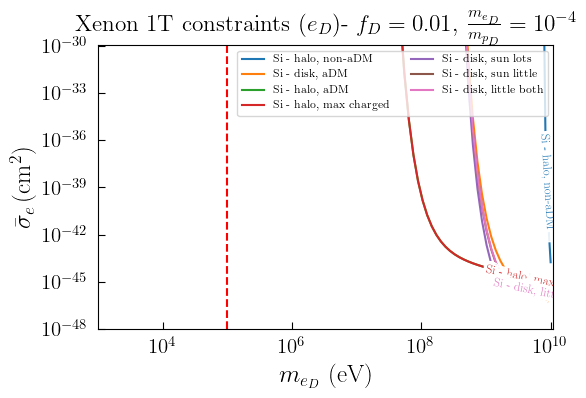

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($e_D$)- $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(9000000099.999926, 6.790516571743358e-13, 'Si - halo, non-aDM'),
 Text(9000000099.999926, 2.7257682561001683e-16, 'Si - disk, aDM'),
 Text(9000000099.999926, 8.239084509437877e-16, 'Si - halo, aDM'),
 Text(9000000099.999926, 8.376508998339419e-16, 'Si - halo, max charged'),
 Text(9000000099.999926, 4.1072987312210916e-16, 'Si - disk, sun lots'),
 Text(9000000099.999926, 3.6207654014504503e-16, 'Si - disk, sun little'),
 Text(9000000099.999926, 3.5810392882656144e-16, 'Si - disk, little both')]

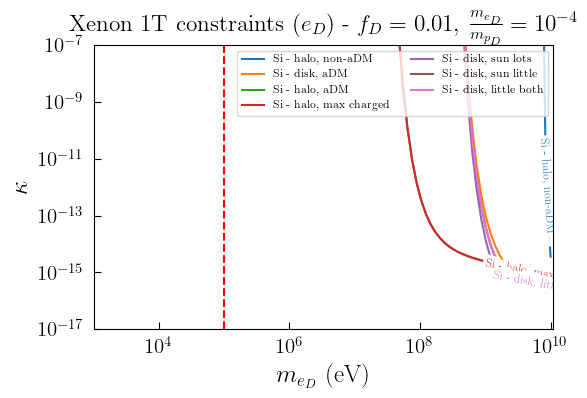

In [ ]:
fig2, axs2 = plt.subplots(figsize=(6,4.2))

for i in range(len(lim_massless)):
    axs2.plot(masslist, lim_massless[i], label=targetlabels[i], color=colors[i])

axs2.set_xscale("log")   
axs2.set_yscale("log")

axs2.set_xlim([1e3,1.1e10])

# choose automatic y-limits from the converted curves
# ymin = min(np.nanmin(arr[np.isfinite(arr) & (arr > 0)]) for arr in lim_kappa)
# ymax = max(np.nanmax(arr[np.isfinite(arr)]) for arr in lim_kappa)
axs2.set_ylim([1e-17, 1e-7])

axs2.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs2.set_ylabel(r"$\kappa$",fontsize=18)
axs2.tick_params(direction="in",which="both")

# axs2.text(5e9, 1e-13, "$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",
        #   fontsize=16, backgroundcolor="white", horizontalalignment="right")

axs2.legend(ncol=2,fontsize=8,loc="upper right")
axs2.axvline(x=1e5,color="red",linestyle="dashed")
axs2.set_title(r"Xenon 1T constraints ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig2.tight_layout()
fig2.subplots_adjust(wspace = 0.3)

props = dict(facecolor='white', alpha=0.9, edgecolor='white', boxstyle="square,pad=0.02")
lines2 = axs2.get_lines()
labelLines(lines2,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# Plot v dists - Dark Electron - SENSEI and Xenon Limits (22/4/26)

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later

sqrtmrat = 1e2

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

targetlabels=["Si - halo, non-aDM","Si - disk, aDM","Si - halo, aDM","Si - halo, max charged","Si - disk, sun lots","Si - disk, sun little","Si - disk, little both"]

vs_list = [{"v0kms": 220,"vesckms":500,"vekms":233,"vdist":"halo","fD":0.01},
            {"v0kms":sqrtmrat * 20,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms": 233,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":30,"vdist":"disk","fD":0.01},\
            {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":30,"vdist":"disk","fD":0.01}] # all must be positive

target_list = [darkelf(target='Si',mX=mX,filename="Si_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

#vdomain = [target_list[i].fv_1d_disk()]

vdom=np.e ** np.linspace(0,np.log(3e5),100)

flist = [(lambda obj: obj.fv_1d_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
flist.insert(0,(lambda obj: obj.fv_1d(vdom/obj.c0))(target_list[0]))

etalist = [(lambda obj: obj.etav_disk(vdom/obj.c0))(target_list[i]) for i in range(1,len(target_list))]
etalist.insert(0,(lambda obj: obj.etav(vdom/obj.c0))(target_list[0]))



 .... Loading files for Si
Loaded Si_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from Y. Sun, H. Xu, B. Da, S.-f. Mao and Z.-j. Ding, Calculations of Energy-Loss Function for 26 Materials, Chinese Journal of Chemical Physics9(2016) 663.
phonon ELF taken or calculated from M. Ikezawa and M. Ishigame, Far-Infrared AbsorptionDue to the Two-Phonon Difference Process in Si, Journal of the Physical Society of Japan 50(1981) 3734.
Loaded Si_epsphonon_data6K.dat for epsilon in phonon regime
Warning, Si_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensities,â in International Tables for Crystallography (American Cancer Society, 2006) Chap. 6.1, pp. 554â595, https://onlinelibrary.wiley.com/doi/pdf/10.

[Text(4.0, 0.33702834656088293, 'Si - halo, non-aDM'),
 Text(100.0, 0.8453992555056282, 'Si - disk, aDM'),
 Text(20.0, 0.0, 'Si - halo, aDM'),
 Text(8.0, 0.0, 'Si - halo, max charged'),
 Text(1.5, 0.0, 'Si - disk, sun lots'),
 Text(10.0, 0.0, 'Si - disk, sun little'),
 Text(100.0, 0.0, 'Si - disk, little both')]

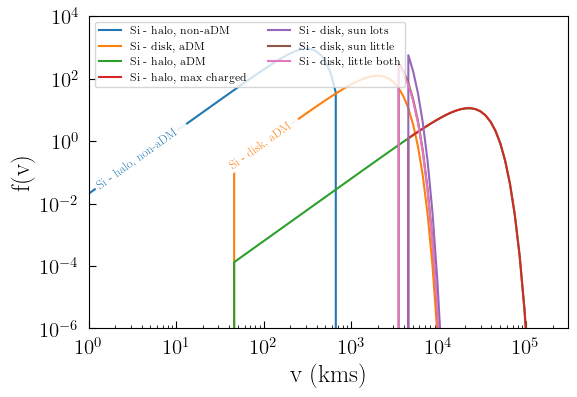

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(flist)):
    axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-6,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel("f(v)",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper left")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 1122.9748745893692, 'Si - halo, non-aDM'),
 Text(100.0, 168.71793767413524, 'Si - disk, aDM'),
 Text(20.0, 15.376281330467549, 'Si - halo, aDM'),
 Text(8.0, 14.852594145241499, 'Si - halo, max charged'),
 Text(1.5, 61.77544045559996, 'Si - disk, sun lots'),
 Text(10.0, 79.49277523439821, 'Si - disk, sun little'),
 Text(100.0, 81.26625771495684, 'Si - disk, little both')]

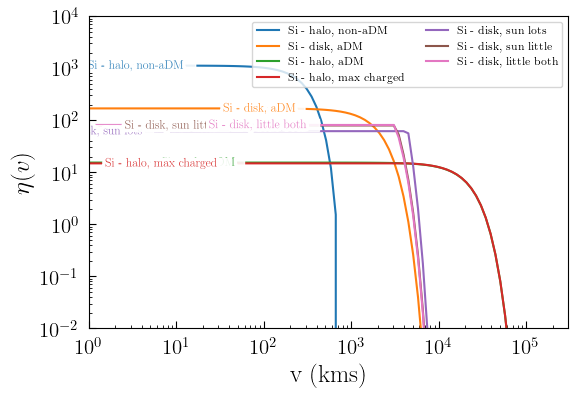

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(etalist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e4])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(4.0, 1122.9748745893678, 'Si - halo, non-aDM'),
 Text(100.0, 168.71793767413507, 'Si - disk, aDM'),
 Text(20.0, 15.376281330467501, 'Si - halo, aDM')]

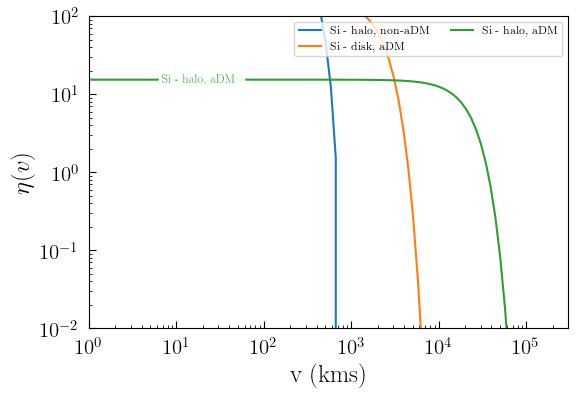

In [ ]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

# for i in range(3):#len(flist)):
#     axs.plot(vdom,flist[i],label=targetlabels[i],color=colors[i])
#     # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    
for i in range(3):#len(flist)):
    axs.plot(vdom,etalist[i],label=targetlabels[i],color=colors[i])
    # axs[1].plot(masslist*1e-6,lim_massive[i],label=targetlabels[i],color=colors[i])
    

axs.set_xscale("log")   
axs.set_xlim([1e0,3e5])

axs.set_yscale("log")
axs.set_ylim([1e-2,1e2])

# axs.set_yscale("log")
# axs.set_ylim([0,1e3])

axs.set_xlabel("v (kms)",fontsize=18)
axs.set_ylabel(r"$\eta(v)$",fontsize=18)
axs.tick_params(direction="in",which="both")
# axs[0].text(8e2,3e-41,"massless mediator",fontsize=16,backgroundcolor="white",horizontalalignment="right")
# axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
# axs.axvline(x=1e5,color="red",linestyle="dashed")
# axs.set_title("DD constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

it seems like the distributions for the halo case are not being given the bump that we expect them to be. Maybe its because the bump is proportional to the ratio of vesc / v0, so for the halo case you don't get a large enhancement. If that's true though, then why is there a difference between the maxed charge case and the not max charged case at all? If \eta is the only way the distribution is feeding in they should look identical.

In [51]:
lim_massless=[]

expSENSEI = 100.72 * 1e-3 / 365 # [kg-yr] SENSEI Snolab exposure from 2312.13342

# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless",exposure=expSENSEI) for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless_DD=np.array(lim_massless) 

Si
Si
Si
Si
Si
Si
Si


In [53]:
task = ("write","read")[0]

# test_read = np.array([])

if task == "write":
    with open("lim_massless_SENSEI_exp_22_4_22", "wb") as f:
        pkl.dump(lim_massless,f)

elif task == "read":
    with open("lim_massless_SENSEI_exp_22_4_22", "rb") as f:
        test_read = pkl.load(f)

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:181: UserWarning: Tried to label line Line2D(_child8), but could not find a label for it.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_cap

[Text(9000000100.0, 6.976804069271544e-35, 'Si - halo, non-aDM'),
 Text(9000000100.0, 2.9428028759285916e-36, 'Si - disk, aDM'),
 Text(9000000100.0, 3.9168290132978904e-36, 'Si - halo, aDM'),
 Text(9000000100.0, 3.9382822866563894e-36, 'Si - halo, max charged'),
 Text(9000000100.0, 1.8112817969479025e-36, 'Si - disk, sun lots'),
 Text(9000000100.0, 1.8187637138277805e-36, 'Si - disk, sun little'),
 Text(9000000100.0, 1.8244063282626823e-36, 'Si - disk, little both')]

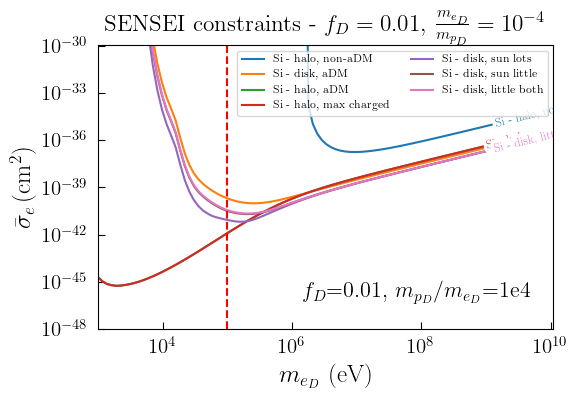

In [54]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_massless)):
    axs.plot(masslist,lim_massless[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

axs.text(5e9,1e-46,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"SENSEI constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

In [ ]:
# convert cm^2 ref cross-section to \kappa
# see eg (2.2) of 1509.01598

alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def sigmae_to_kappa_exact(sigmae_cm2, mchi_eV):
    mu = mu_chie_GeV(mchi_eV)
    sigmae_GeVminus2 = np.asarray(sigmae_cm2, dtype=float) / cm2_per_GeVminus2
    return (alpha * m_e_GeV**2 / (4*np.sqrt(np.pi)*mu)) * np.sqrt(sigmae_GeVminus2)

lim_kappa = [sigmae_to_kappa_exact(lim_massless[i], masslist) for i in range(len(lim_massless))]

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(9999999999.999918), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(9999999999.999918), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 2 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(9999999999.999918), xval=20)

[Text(9000000099.999926, 2.2247908321296107e-10, 'Si - halo, non-aDM'),
 Text(9000000099.999926, 4.569208105526313e-11, 'Si - disk, aDM'),
 Text(9000000099.999926, 5.271420027160026e-11, 'Si - halo, aDM'),
 Text(9000000099.999926, 5.285836634059556e-11, 'Si - halo, max charged'),
 Text(9000000099.999926, 3.584704234390484e-11, 'Si - disk, sun lots'),
 Text(9000000099.999926, 3.592100363960781e-11, 'Si - disk, sun little'),
 Text(9000000099.999926, 3.5976682034810325e-11, 'Si - disk, little both')]

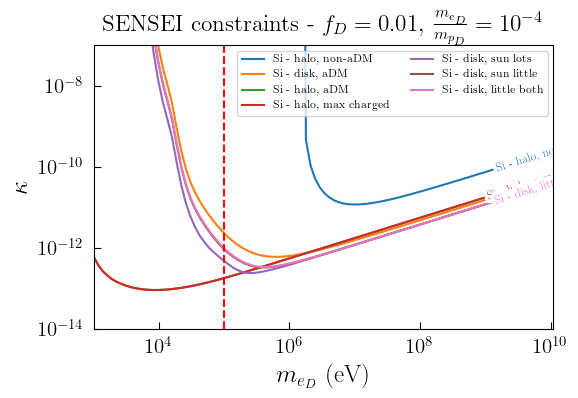

In [58]:
fig2, axs2 = plt.subplots(figsize=(6,4.2))

for i in range(len(lim_kappa)):
    axs2.plot(masslist, lim_kappa[i], label=targetlabels[i], color=colors[i])

axs2.set_xscale("log")   
axs2.set_yscale("log")

axs2.set_xlim([1e3,1.1e10])

# choose automatic y-limits from the converted curves
# ymin = min(np.nanmin(arr[np.isfinite(arr) & (arr > 0)]) for arr in lim_kappa)
# ymax = max(np.nanmax(arr[np.isfinite(arr)]) for arr in lim_kappa)
axs2.set_ylim([1e-14, 1e-7])

axs2.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs2.set_ylabel(r"$\kappa$",fontsize=18)
axs2.tick_params(direction="in",which="both")

# axs2.text(5e9, 1e-13, "$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",
        #   fontsize=16, backgroundcolor="white", horizontalalignment="right")

axs2.legend(ncol=2,fontsize=8,loc="upper right")
axs2.axvline(x=1e5,color="red",linestyle="dashed")
axs2.set_title(r"SENSEI constraints - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig2.tight_layout()
fig2.subplots_adjust(wspace = 0.3)

props = dict(facecolor='white', alpha=0.9, edgecolor='white', boxstyle="square,pad=0.02")
lines2 = axs2.get_lines()
labelLines(lines2,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

### Now Nuclear

In [60]:
from millicharge_nr import attach_mc_nr_methods
attach_mc_nr_methods(darkelf)

def get_limit_nuclear(
    target,
    mX,
    material="Xe",
    mediator="massless",
    exposure=1,
    q_dm=1.0,
    kappa_ref=1e-9,
    ER_min_eV=None,
    ER_max_eV=None,
):
    target.update_params(mX=mX, mediator=mediator)

    R = target.R_mc(
        material=material,
        kappa=kappa_ref,
        q_dm=q_dm,
        vdist=target.vdist,
        ER_min_eV=ER_min_eV,
        ER_max_eV=ER_max_eV,
    )

    if R == 0.0:
        return 1.0
    else:
        return kappa_ref * np.sqrt(3.0 / (R * exposure))

In [61]:
lim_massless=[]

expXENON1T = 1000.0   # [kg-yr] = 1 tonne-year

for target in target_list:
    print(target.target)
    lim_massless.append([
        get_limit_nuclear(
            target,
            mX,
            material="Xe",
            mediator="massless",
            exposure=expXENON1T,
            q_dm=1.0,
        )
        for mX in masslist
    ])

lim_massless_DD = np.array(lim_massless)

Si
Si
Si
Si
Si
Si
Si


In [79]:
alpha = 1/137.035999084
m_e_GeV = 0.00051099895
cm2_per_GeVminus2 = 0.389379e-27

def mu_chie_GeV(mchi_eV):
    mchi_GeV = np.asarray(mchi_eV, dtype=float) * 1e-9
    return (mchi_GeV * m_e_GeV) / (mchi_GeV + m_e_GeV)

def kappa_to_sigmae_exact(kappa, mchi_eV):
    """
    Inverse of sigmae_to_kappa_exact using the same convention:
        kappa = (alpha m_e^2 / (4 sqrt(pi) mu)) * sqrt(sigmae)

    Therefore:
        sigmae = [4 sqrt(pi) mu kappa / (alpha m_e^2)]^2

    Inputs
    ------
    kappa : float or array
        Millicharge / kinetic-mixing parameter in your convention.
    mchi_eV : float or array
        DM mass in eV.

    Returns
    -------
    sigmae_cm2 : float or array
        Reference electron cross section in cm^2
    """
    mu = mu_chie_GeV(mchi_eV)

    pref = (4*np.sqrt(np.pi) * mu * np.asarray(kappa, dtype=float)) / (alpha * m_e_GeV**2)

    sigmae_GeVminus2 = pref**2

    return sigmae_GeVminus2 * cm2_per_GeVminus2


# Example: convert your kappa-limit arrays back to sigmae arrays
lim_sigmae = [
    kappa_to_sigmae_exact(lim_massless[i], masslist)
    for i in range(len(lim_massless))
]

c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 0 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=4). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 1 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=100.0). Clipping it into the allowed range.
  warnings.warn(
c:\Users\keega\OneDrive\Documents\THEP\aDM Capture\notebooks\AdM_capture\DarkELF-main\.venv\lib\site-packages\labellines\core.py:267: UserWarning: The value at position 2 in `xvals` is outside the range of its associated line (xmin=np.float64(1000.0), xmax=np.float64(10000000000.0), xval=20). Clipping i

[Text(9000000100.0, 9.716342880351971e-40, 'Si - halo, non-aDM'),
 Text(9000000100.0, 1.0477300439682207e-46, 'Si - disk, aDM'),
 Text(9000000100.0, 9.563887745728942e-46, 'Si - halo, aDM'),
 Text(9000000100.0, 9.885526317349894e-46, 'Si - halo, max charged'),
 Text(9000000100.0, 2.376765090153085e-46, 'Si - disk, sun lots'),
 Text(9000000100.0, 1.847032134313585e-46, 'Si - disk, sun little'),
 Text(9000000100.0, 1.806724148892086e-46, 'Si - disk, little both')]

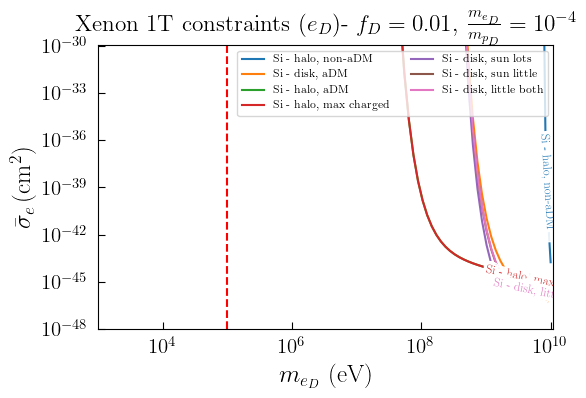

In [85]:
fig, axs = plt.subplots(figsize=(6,4.2))

cmap = plt.get_cmap('tab10')
colors = cmap(np.linspace(0.0,1.0,10))

for i in range(len(lim_sigmae)):
    axs.plot(masslist,lim_sigmae[i],label=targetlabels[i],color=colors[i])
    
    
axs.set_xscale("log")   
axs.set_yscale("log")

axs.set_xlim([1e3,1.1e10])
axs.set_ylim([1e-48,1.1e-30])
axs.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs.set_ylabel(r"$\bar\sigma_e\,(\mathrm{cm}^2)$",fontsize=18)
axs.tick_params(direction="in",which="both")

# axs.text(5e9,1e-21,"$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",fontsize=16,backgroundcolor="white",horizontalalignment="right")

axs.legend(ncol=2,fontsize=8,loc="upper right")
axs.axvline(x=1e5,color="red",linestyle="dashed")
axs.set_title(r"Xenon 1T constraints ($e_D$)- $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig.tight_layout()
fig.subplots_adjust(wspace = 0.3)


props = dict(facecolor='white', alpha=0.9, edgecolor='white',boxstyle="square,pad=0.02")
lines = axs.get_lines()
labelLines(lines,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

[Text(9000000099.999926, 6.790516571743358e-13, 'Si - halo, non-aDM'),
 Text(9000000099.999926, 2.7257682561001683e-16, 'Si - disk, aDM'),
 Text(9000000099.999926, 8.239084509437877e-16, 'Si - halo, aDM'),
 Text(9000000099.999926, 8.376508998339419e-16, 'Si - halo, max charged'),
 Text(9000000099.999926, 4.1072987312210916e-16, 'Si - disk, sun lots'),
 Text(9000000099.999926, 3.6207654014504503e-16, 'Si - disk, sun little'),
 Text(9000000099.999926, 3.5810392882656144e-16, 'Si - disk, little both')]

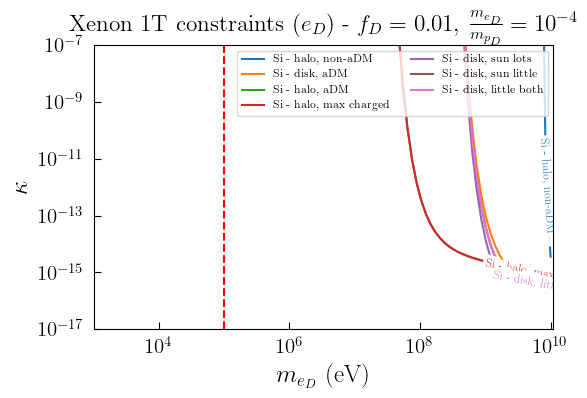

In [86]:
fig2, axs2 = plt.subplots(figsize=(6,4.2))

for i in range(len(lim_massless)):
    axs2.plot(masslist, lim_massless[i], label=targetlabels[i], color=colors[i])

axs2.set_xscale("log")   
axs2.set_yscale("log")

axs2.set_xlim([1e3,1.1e10])

# choose automatic y-limits from the converted curves
# ymin = min(np.nanmin(arr[np.isfinite(arr) & (arr > 0)]) for arr in lim_kappa)
# ymax = max(np.nanmax(arr[np.isfinite(arr)]) for arr in lim_kappa)
axs2.set_ylim([1e-17, 1e-7])

axs2.set_xlabel("$m_{e_D}$ (eV)",fontsize=18)
axs2.set_ylabel(r"$\kappa$",fontsize=18)
axs2.tick_params(direction="in",which="both")

# axs2.text(5e9, 1e-13, "$f_D$=0.01, $m_{p_D}/m_{e_D}$=1e4",
        #   fontsize=16, backgroundcolor="white", horizontalalignment="right")

axs2.legend(ncol=2,fontsize=8,loc="upper right")
axs2.axvline(x=1e5,color="red",linestyle="dashed")
axs2.set_title(r"Xenon 1T constraints ($e_D$) - $f_D = 0.01$, $\frac{m_{e_D}}{m_{p_D}} = 10^{-4}$")

fig2.tight_layout()
fig2.subplots_adjust(wspace = 0.3)

props = dict(facecolor='white', alpha=0.9, edgecolor='white', boxstyle="square,pad=0.02")
lines2 = axs2.get_lines()
labelLines(lines2,fontsize=9,xvals=[4,1e2,20,8,1.5,10,100,10],zorder=2.5,
           ha='center',va='center',align=True,bbox=props)

# vmin plots

In [ ]:

threshold=self.E_gap+self.e0
kin_emax = self.ommax

 if (Emax < 1.0):
        Emax = np.min([self.ommax, kin_emax])
    else:
        Emax = np.min([self.ommax, kin_emax, Emax])

omega=np.linspace(threshold,Emax,200)


kmin_eps = np.sqrt(2*self.me * omega[i] + self.kF**2) - self.kF
kmax_eps = np.sqrt(2*self.me * omega[i] + self.kF**2) + self.kF

        

2.9

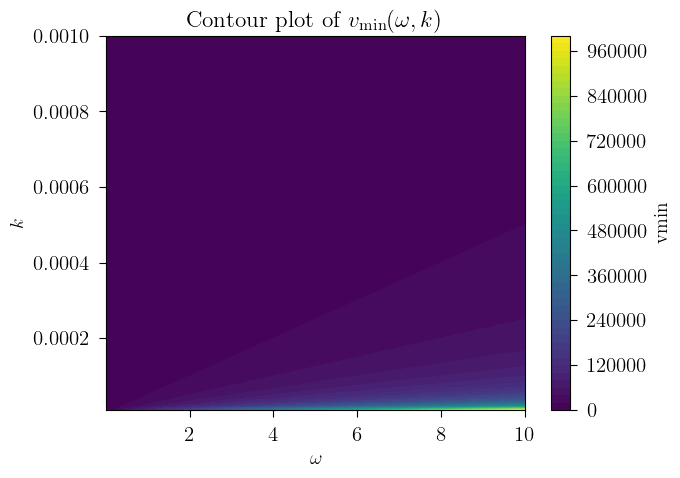

In [ ]:
# pick your darkelf object
target = target_list[0]

# choose ranges for omega and k
omega_vals = np.linspace(1e-3, 10, 100)   # adjust as needed
k_vals = np.linspace(1e-5, 1e-3, 100)       # avoid k=0 because vmin has omega/k and delta/k

# build 2D grid
Omega, K = np.meshgrid(omega_vals, k_vals, indexing='xy')

# evaluate vmin on the grid
Vmin = target.vmin(Omega, K)

# make contour plot
plt.figure(figsize=(7, 5))
cs = plt.contourf(Omega, K, Vmin, levels=50)
plt.colorbar(cs, label='vmin')
plt.xlabel(r'$\omega$')
plt.ylabel(r'$k$')
plt.title(r'Contour plot of $v_{\min}(\omega,k)$')
plt.tight_layout()
plt.show()

In [ ]:
def build_vmin_kinematic_grid(delfobj, Emax=0.0, n_omega=200, n_k=300):
    """
    Build a rectangular (omega, k) grid covering the allowed kinematic region,
    and mask points outside kmin_eps(omega) <= k <= kmax_eps(omega).

    Parameters
    ----------
    delfobj : darkelf object
        The darkelf object to use.
    Emax : float
        Upper omega cutoff. If Emax < 1.0, use min(delfobj.ommax, kin_emax),
        matching your snippet.
    n_omega : int
        Number of omega points.
    n_k : int
        Number of k points in the global k range.

    Returns
    -------
    Omega : 2D array
        Meshgrid of omega values.
    K : 2D array
        Meshgrid of k values.
    Vmin_masked : 2D masked array
        vmin evaluated on the grid, masked outside the allowed kinematic band.
    kmin_eps : 1D array
        Lower k boundary for each omega.
    kmax_eps : 1D array
        Upper k boundary for each omega.
    omega : 1D array
        Omega values used.
    """
    threshold = delfobj.E_gap + delfobj.e0
    kin_emax = delfobj.ommax

    if Emax < 1.0:
        Emax_use = min(delfobj.ommax, kin_emax)
    else:
        Emax_use = min(delfobj.ommax, kin_emax, Emax)

    omega = np.linspace(threshold, Emax_use, n_omega)

    kmin_eps = np.sqrt(2 * delfobj.me * omega + delfobj.kF**2) - delfobj.kF
    kmax_eps = np.sqrt(2 * delfobj.me * omega + delfobj.kF**2) + delfobj.kF

    # global rectangular k-grid spanning the full allowed band
    k_global_min = np.min(kmin_eps)
    k_global_max = np.max(kmax_eps)
    k = np.linspace(k_global_min, k_global_max, n_k)

    Omega, K = np.meshgrid(omega, k, indexing='xy')

    # vmin on the full rectangular grid
    Vmin = delfobj.vmin(Omega, K)

    # mask outside the allowed kinematic region
    kmin_2d = kmin_eps[np.newaxis, :]
    kmax_2d = kmax_eps[np.newaxis, :]
    allowed = (K >= kmin_2d) & (K <= kmax_2d)

    Vmin_masked = np.ma.array(Vmin, mask=~allowed)

    return Omega, K, Vmin_masked, kmin_eps, kmax_eps, omega

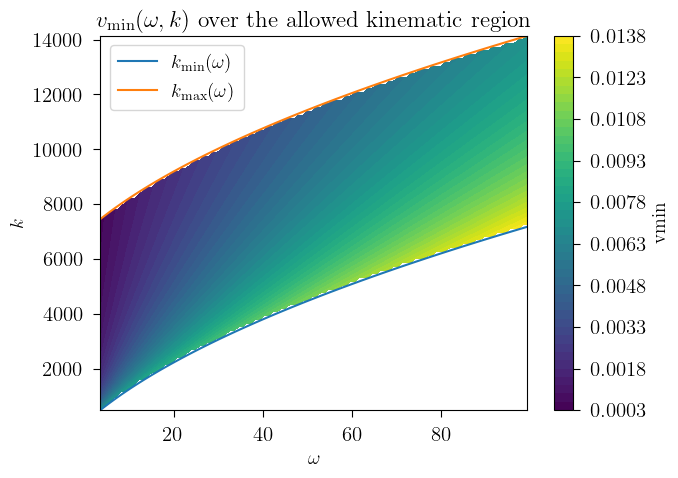

In [ ]:
# pick your darkelf object
target = target_list[0]

Omega, K, Vmin_masked, kmin_eps, kmax_eps, omega = build_vmin_kinematic_grid(
    target,
    Emax=0.0,      # set < 1.0 to use your default logic
    n_omega=100,
    n_k=100
)

plt.figure(figsize=(7, 5))

cs = plt.contourf(Omega, K, Vmin_masked, levels=50)
plt.colorbar(cs, label='vmin')

# overlay the kinematic boundaries
plt.plot(omega, kmin_eps, linewidth=1.5, label=r'$k_{\min}(\omega)$')
plt.plot(omega, kmax_eps, linewidth=1.5, label=r'$k_{\max}(\omega)$')

plt.xlabel(r'$\omega$')
plt.ylabel(r'$k$')
plt.title(r'$v_{\min}(\omega,k)$ over the allowed kinematic region')
plt.legend()
plt.tight_layout()
plt.show()

# Scan over mass ratio

In [ ]:
asslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["v0 = {}".format(str(n)) for n in np.linspace(1,4,8)]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 2 * 10**n,"vesckms":1.1 * 10**n,"vekms":2 * 10**n,"vdist":"disk","fD":0.01} for n in np.linspace(1,4,8)]# all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

# Ve to 0

In [ ]:
def get_limit(target,mX,threshold=-1.0,method="grid",mediator="massless",kcut=0.0):
    
    target.update_params(mX=mX,mediator=mediator)
    R=target.R_electron(threshold=threshold,method=method,sigmae=1e-38,kcut=kcut,vdist=target.vdist)
    if R==0.0:
        return 1.0
    else:
        return 3.0*1.0e-38/R

In [ ]:
masslist=np.logspace(3,10,100)
kcut=1.2e4 # restrict phase space for massive mediator

mX=1.0e8 # specify the dark matter mass (to be updated later)

# target_list=[Ge,Si,SiO2]
# target_list=[Ge]

sqrtmrat = 1e2
# uppervcutfactor = 10

# targetlabels=["Ge - halo, uncharged","Ge - halo, max charged","Ge - disk, grav","Ge - disk, earth lots","Ge - disk, earth little","Ge - disk, sun lots","Ge - disk, sun little"]
targetlabels=["Ge - halo, non-aDM","Ge - halo, aDM","Ge - halo, max charged","Ge - disk, sun lots","Ge - disk, sun little","Ge - disk, little both"]

# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240},{"v0kms":20,"vesckms":11,"vekms":20},{"v0kms":20,"vesckms":11,"vekms":20}] # all must be positive
# vs_list = [{"v0kms":220,"vesckms":500,"vekms":240,"vdist":"halo","vescdiskkms":0},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":11},\
#            {"v0kms":sqrtmrat * 20,"vesckms":uppervcutfactor * sqrtmrat * 20,"vekms":sqrtmrat * 20,"vdist":"disk","vescdiskkms":sqrtmrat * 11}] # all must be positive
vs_list = [{"v0kms": 220,"vesckms":500,"vekms":240,"vdist":"halo","fD":0.01},\
        #    {"v0kms":sqrtmrat * 20,"vesckms":11,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms": np.sqrt(43**2 + 11**2),"vekms":0,"vdist":"disk","fD":0.01},\
           {"v0kms":sqrtmrat * 220,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":0,"vdist":"disk","fD":0.01},\
            #  {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * 11 / 2,"vekms":sqrtmrat * 20,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 + 11**2),"vekms":0,"vdist":"disk","fD":0.01},\
             {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2),"vekms":0,"vdist":"disk","fD":0.01},\
                {"v0kms":sqrtmrat * 20,"vesckms":sqrtmrat * np.sqrt(43**2 / 2 + 11**2 / 2),"vekms":0,"vdist":"disk","fD":0.01}] # all must be positive

# target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"],vescdiskkms=v["vescdiskkms"]) for v in vs_list]
target_list = [darkelf(target='Ge',mX=mX,filename="Ge_mermin.dat",vesckms=v["vesckms"],v0kms=v["v0kms"],vekms=v["vekms"],vdist=v["vdist"]) for v in vs_list]

lim_massless=[]
# lim_massive=[]
for target in target_list:
    print(target.target)
    # for v in vs_list:
    #     print(v)
    if target.target=="Al":
        # for Al, take 5 eV threshold
        lim_massless.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,threshold=5.0,method="grid",mediator="massive",kcut=kcut) for mX in masslist])
    else:
        # for the others, take the default threshold (2e- or 2 x bandgap)
        lim_massless.append([get_limit(target,mX,method="grid",mediator="massless") for mX in masslist])
        # lim_massive.append([get_limit(target,mX,method="grid",mediator="massive",kcut=kcut) for mX in masslist])

lim_massless=np.array(lim_massless) 
# lim_massive=np.array(lim_massive)

Anisotropic calculations unavailable for Ge
 .... Loading files for Ge
Loaded Ge_mermin.dat for epsilon in electron regime
electronic ELF taken or calculated from M. Nov Ìak, L. K Ìov Ìer, S. Egri, I. Cserny, J. T Ìoth, D. Varga et al., A simple statistical model for quantitative analysis of plasmon structures in xps and auger spectra of free-electron-like materials,Journal ofElectron Spectroscopy and Related Phenomena163(2008) 7
phonon ELF taken or calculated from M. Ikezawa and T. Nanba, Two-Phonon Difference Absorption Spectra in Ge Crystals, Journal of  the Physical Society of Japan 45 (1978) 148.
Loaded Ge_epsphonon_data2K.dat for epsilon in phonon regime
Warning, Ge_eps_electron_opticallimit.dat does not exist! dielectric function in optical limit not loaded. Needed for absorption calculations in superconductors.
Zion(k) for Migdal calculation taken or calculated from: P. J. Brown, A. G. Fox, E. N. Maslen, M. A. OKeefe,and B. T. M. Willis, âIntensity of diffracted intensiti